In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from itertools import combinations
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

In [20]:
data = pd.read_csv("CC GENERAL.csv")
data = data.drop('CUST_ID', axis=1)
data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [21]:
con_stats = []
for feature in data.columns:
    stat = {
        'Feature': feature,
        'Amount': len(data[feature]),
        'Missing %': (data[feature].isna().sum() / len(data[feature])) * 100, 
        'Cardinality': data[feature].nunique(),
        'Max value': data[feature].max(),
        'Min value': data[feature].min(),
        'First quartile': data[feature].quantile(0.25),
        'Third quartile': data[feature].quantile(0.75),
        'Mean': data[feature].mean(),
        'Median': data[feature].median(),
        'Standard deviation': data[feature].std()
    }
    con_stats.append(stat)

con_stats_df = pd.DataFrame(con_stats)
con_stats_df.set_index('Feature', inplace=True)
con_stats_df

,Amount,Missing %,Cardinality,Max value,Min value,First quartile,Third quartile,Mean,Median,Standard deviation
Feature,,,,,,,,,,
BALANCE,8950,0.000000,8871,19043.13856,0.000000,128.281915,2054.140036,1564.474828,873.385231,2081.531879
BALANCE_FREQUENCY,8950,0.000000,43,1.00000,0.000000,0.888889,1.000000,0.877271,1.000000,0.236904
PURCHASES,8950,0.000000,6203,49039.57000,0.000000,39.635000,1110.130000,1003.204834,361.280000,2136.634782
ONEOFF_PURCHASES,8950,0.000000,4014,40761.25000,0.000000,0.000000,577.405000,592.437371,38.000000,1659.887917
INSTALLMENTS_PURCHASES,8950,0.000000,4452,22500.00000,0.000000,0.000000,468.637500,411.067645,89.000000,904.338115
CASH_ADVANCE,8950,0.000000,4323,47137.21176,0.000000,0.000000,1113.821139,978.871112,0.000000,2097.163877
PURCHASES_FREQUENCY,8950,0.000000,47,1.00000,0.000000,0.083333,0.916667,0.490351,0.500000,0.401371
ONEOFF_PURCHASES_FREQUENCY,8950,0.000000,47,1.00000,0.000000,0.000000,0.300000,0.202458,0.083333,0.298336
PURCHASES_INSTALLMENTS_FREQUENCY,8950,0.000000,47,1.00000,0.000000,0.000000,0.750000,0.364437,0.166667,0.397448


In [22]:
data = data.dropna()
data = data.drop(['BALANCE_FREQUENCY', 
                  'PURCHASES_FREQUENCY', 
                  'ONEOFF_PURCHASES_FREQUENCY',
                  'PURCHASES_INSTALLMENTS_FREQUENCY',
                  'PRC_FULL_PAYMENT',
                  'TENURE',
                  ], axis=1)

con_stats = []
for feature in data.columns:
    stat = {
        'Feature': feature,
        'Amount': len(data[feature]),
        'Missing %': (data[feature].isna().sum() / len(data[feature])) * 100, 
        'Cardinality': data[feature].nunique(),
        'Max value': data[feature].max(),
        'Min value': data[feature].min(),
        'First quartile': data[feature].quantile(0.25),
        'Third quartile': data[feature].quantile(0.75),
        'Mean': data[feature].mean(),
        'Median': data[feature].median(),
        'Standard deviation': data[feature].std()
    }
    con_stats.append(stat)

con_stats_df = pd.DataFrame(con_stats)
con_stats_df.set_index('Feature', inplace=True)
con_stats_df

,Amount,Missing %,Cardinality,Max value,Min value,First quartile,Third quartile,Mean,Median,Standard deviation
Feature,,,,,,,,,,
BALANCE,8636,0.0,8631,19043.13856,0.000000,148.095189,2105.195853,1601.224893,916.855459,2095.571300
PURCHASES,8636,0.0,6015,49039.57000,0.000000,43.367500,1145.980000,1025.433874,375.405000,2167.107984
ONEOFF_PURCHASES,8636,0.0,3922,40761.25000,0.000000,0.000000,599.100000,604.901438,44.995000,1684.307803
INSTALLMENTS_PURCHASES,8636,0.0,4341,22500.00000,0.000000,0.000000,484.147500,420.843533,94.785000,917.245182
CASH_ADVANCE,8636,0.0,4206,47137.21176,0.000000,0.000000,1132.385490,994.175523,0.000000,2121.458303
CASH_ADVANCE_FREQUENCY,8636,0.0,54,1.50000,0.000000,0.000000,0.250000,0.137604,0.000000,0.201791
CASH_ADVANCE_TRX,8636,0.0,65,123.00000,0.000000,0.000000,4.000000,3.313918,0.000000,6.912506
PURCHASES_TRX,8636,0.0,173,358.00000,0.000000,1.000000,18.000000,15.033233,7.000000,25.180468
CREDIT_LIMIT,8636,0.0,203,30000.00000,50.000000,1600.000000,6500.000000,4522.091030,3000.000000,3659.240379


In [23]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)

IQR = Q3 - Q1

data_clean = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

continuous_cols = [col for col in data_clean.columns if data_clean[col].nunique() >= 50]
data_cont = data_clean[continuous_cols]

scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_cont), columns=continuous_cols)
data_scaled.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS
0,-0.805690,-0.699902,-0.604747,-0.382513,-0.561305,-0.897822,-0.822601,-0.651558
1,1.634862,0.800192,1.607593,-0.729293,-0.561305,1.679603,-0.236043,0.803874
2,-0.033211,-0.875636,-0.558965,-0.729293,-0.561305,-0.818517,-0.157510,-0.337418
3,0.967113,0.054384,-0.604747,0.856295,-0.561305,-0.382337,-0.156491,0.519663
4,0.162900,0.995669,1.288033,-0.002292,-0.561305,1.481339,-0.143632,-0.136988


In [24]:
results = []
for col1, col2 in combinations(continuous_cols, 2):
    X = data_scaled[[col1, col2]].values
    db = DBSCAN(eps=0.5, min_samples=5).fit(X)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = (labels == -1).sum()
    score = silhouette_score(X[labels != -1], labels[labels != -1]) if n_clusters > 1 else -1
    results.append({'Attribute 1': col1, 'Attribute 2': col2, 'Clusters': n_clusters, 'Noise points': noise, 'Silhouette score': round(score, 4)})

results_df = pd.DataFrame(results).sort_values('Silhouette score', ascending=False)
results_df

,Attribute 1,Attribute 2,Clusters,Noise points,Silhouette score
1,BALANCE,ONEOFF_PURCHASES,2,1,0.6546
0,BALANCE,PURCHASES,2,12,0.6225
11,PURCHASES,PAYMENTS,4,11,0.6001
12,PURCHASES,MINIMUM_PAYMENTS,2,6,0.5837
3,BALANCE,CASH_ADVANCE,1,0,-1.0000
4,BALANCE,CREDIT_LIMIT,1,1,-1.0000
6,BALANCE,MINIMUM_PAYMENTS,1,1,-1.0000
5,BALANCE,PAYMENTS,1,7,-1.0000
7,PURCHASES,ONEOFF_PURCHASES,1,0,-1.0000
8,PURCHASES,INSTALLMENTS_PURCHASES,1,0,-1.0000


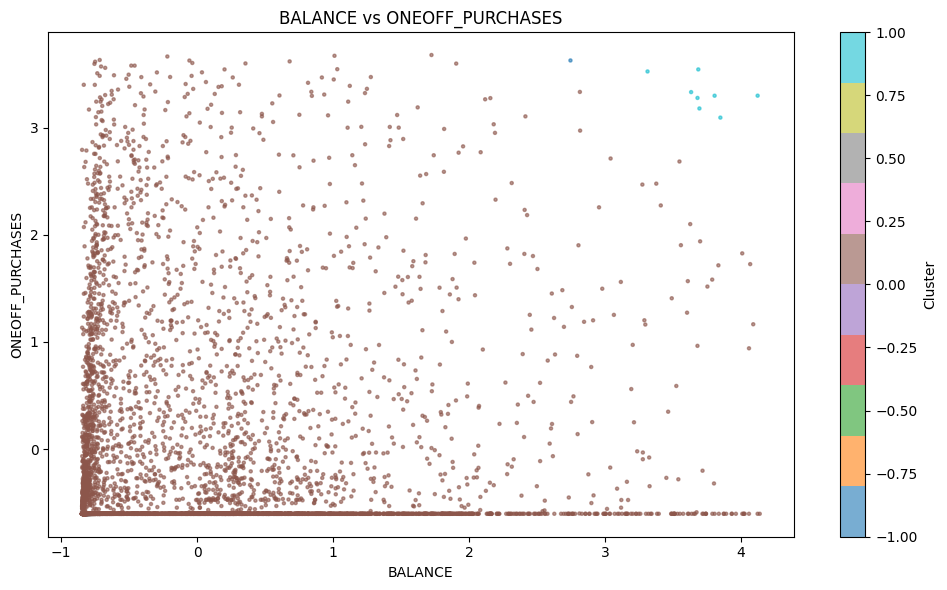

In [25]:
best = results_df.iloc[0]
col1, col2 = best['Attribute 1'], best['Attribute 2']
X = data_scaled[[col1, col2]].values

db = DBSCAN(eps=0.5, min_samples=5).fit(X)
labels = db.labels_

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=5, alpha=0.6)
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f'{col1} vs {col2}')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

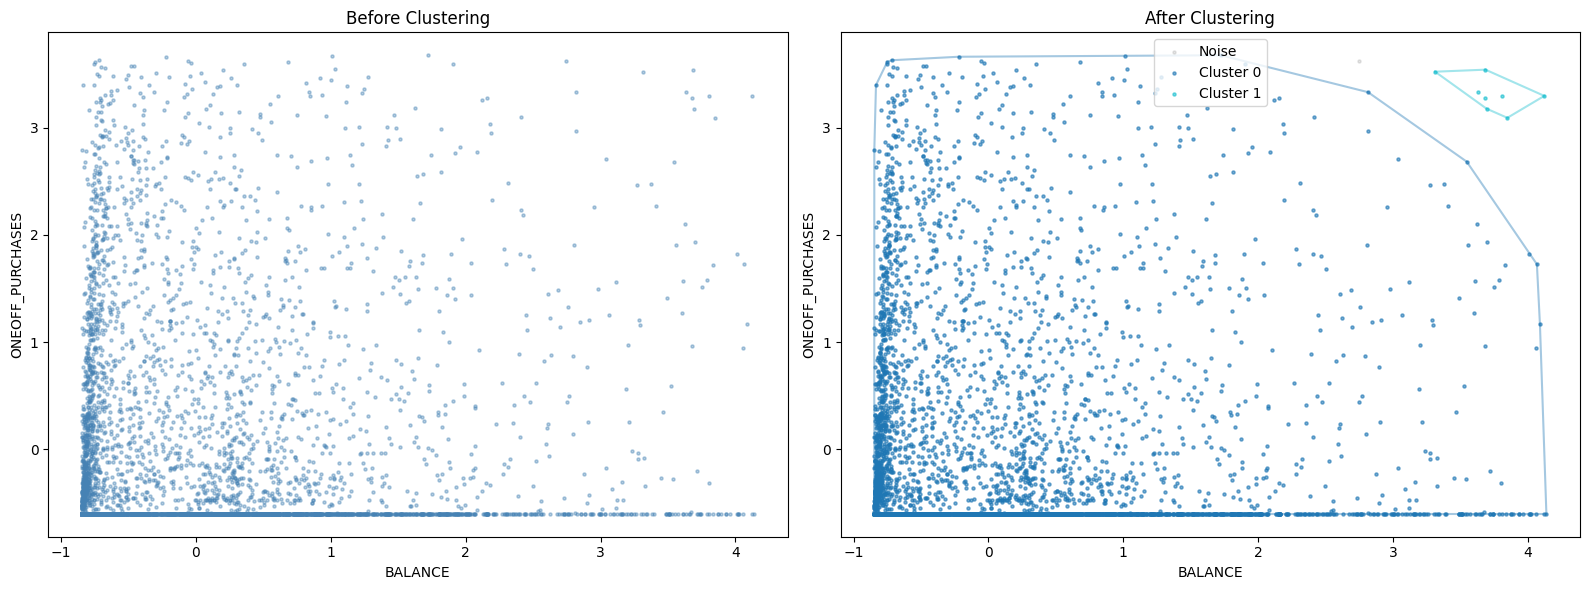

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X[:, 0], X[:, 1], s=5, alpha=0.4, color='steelblue')
axes[0].set_xlabel(col1)
axes[0].set_ylabel(col2)
axes[0].set_title('Before Clustering')

unique_labels = sorted(set(labels))
colors = plt.cm.tab10(np.linspace(0, 1, len([l for l in unique_labels if l != -1])))

color_idx = 0
for label in unique_labels:
    mask = labels == label
    if label == -1:
        axes[1].scatter(X[mask, 0], X[mask, 1], s=5, alpha=0.2, color='grey', label='Noise')
    else:
        color = colors[color_idx]
        axes[1].scatter(X[mask, 0], X[mask, 1], s=5, alpha=0.6, color=color, label=f'Cluster {label}')
        if mask.sum() >= 3:
            hull = ConvexHull(X[mask])
            for simplex in hull.simplices:
                axes[1].plot(X[mask][simplex, 0], X[mask][simplex, 1], color=color, alpha=0.4)
        color_idx += 1

axes[1].set_xlabel(col1)
axes[1].set_ylabel(col2)
axes[1].set_title('After Clustering')
axes[1].legend()

plt.tight_layout()
plt.show()